# Tabular Sensor Anomaly Detection (Parquet-backed CSV)

Trains classical + advanced tabular models for anomaly classification. Evaluation uses F1 and per-class accuracy (implemented as per-class recall). Finally, generates a `submission.csv`.

In [21]:
# =============================
# Install dependencies (best-effort)
# =============================

import importlib
import subprocess
import sys
from typing import Optional


def ensure_import(import_name: str, pip_name: Optional[str] = None) -> None:
    try:
        importlib.import_module(import_name)
        print(f"[OK] {import_name}")
    except Exception:
        pkg = pip_name or import_name
        print(f"[Install] {pkg}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])


# Core
ensure_import("numpy")
ensure_import("pandas")
ensure_import("pyarrow")
ensure_import("sklearn", "scikit-learn")
ensure_import("matplotlib")
ensure_import("seaborn")

# Optional
ensure_import("imbalanced_learn", "imbalanced-learn")

# Advanced models (optional; skip if installation fails)
# XGBoost/LightGBM often require OpenMP runtime (libomp) on macOS.
import os


def configure_omp_dylib() -> None:
    """Best-effort: set DYLD_LIBRARY_PATH so libomp.dylib can be found."""
    import sys
    conda_prefix = os.environ.get("CONDA_PREFIX")
    candidates = [
        "/opt/homebrew/opt/libomp/lib",
        "/usr/local/opt/libomp/lib",
        "/opt/local/lib",
        # common conda base locations
        "/opt/anaconda3/lib",
        # Conda environments
        (os.path.join(conda_prefix, "lib") if conda_prefix else None),
        os.path.join(sys.prefix, "lib"),
    ]
    # Drop Nones
    candidates = [c for c in candidates if c]
    for d in candidates:
        lib_path = os.path.join(d, "libomp.dylib")
        if os.path.exists(lib_path):
            prev = os.environ.get("DYLD_LIBRARY_PATH", "")
            os.environ["DYLD_LIBRARY_PATH"] = d + (":" + prev if prev else "")
            print("[OK] libomp found:", lib_path)
            return
    print("[Warn] libomp.dylib not found. XGBoost/LightGBM may fail to load. Consider installing an OpenMP runtime (e.g., via conda/llvm-openmp).")


configure_omp_dylib()


for import_name in ["xgboost", "lightgbm", "catboost"]:
    try:
        __import__(import_name)
        print(f"[OK] {import_name}")
    except Exception as e:
        print(f"[Skip] {import_name}: {e}")


[OK] numpy
[OK] pandas
[OK] pyarrow
[OK] sklearn
[OK] matplotlib
[OK] seaborn
[Install] imbalanced-learn


dyld[21892]: symbol '__ZNKSt3__119bad_expected_accessIvE4whatEv' missing from root that overrides /usr/lib/libc++.1.dylib. Use of that symbol in /System/Library/PrivateFrameworks/IsolatedCoreAudioClient.framework/Versions/A/IsolatedCoreAudioClient is being set to 0xBAD4007.
dyld[21892]: symbol '__ZTINSt3__119bad_expected_accessIvEE' missing from root that overrides /usr/lib/libc++.1.dylib. Use of that symbol in /System/Library/PrivateFrameworks/IsolatedCoreAudioClient.framework/Versions/A/IsolatedCoreAudioClient is being set to 0xBAD4007.
dyld[21892]: symbol '__ZTINSt3__13pmr15memory_resourceE' missing from root that overrides /usr/lib/libc++.1.dylib. Use of that symbol in /System/Library/PrivateFrameworks/caulk.framework/Versions/A/caulk is being set to 0xBAD4007.
dyld[21892]: symbol '__ZNKSt3__119bad_expected_accessIvE4whatEv' missing from root that overrides /usr/lib/libc++.1.dylib. Use of that symbol in /System/Library/PrivateFrameworks/IsolatedCoreAudioClient.framework/Versions/A/

[OK] libomp found: /opt/anaconda3/lib/libomp.dylib
[Skip] xgboost: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/pranavanand/Desktop/Kaggle/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/pranavanand/Desktop/Kaggle/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/Sys

In [22]:
# =============================
# Imports + config
# =============================

import os
from dataclasses import dataclass, field

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import warnings

warnings.filterwarnings("ignore")


@dataclass(frozen=True)
class Config:
    train_path: str = "trainparquet.csv"
    test_path: str = "testparquet.csv"
    id_col: str = "ID"
    date_col: str = "Date"
    target_col: str = "target"
    sensor_cols: tuple[str, ...] = ("X1", "X2", "X3", "X4", "X5")
    random_state: int = 42
    valid_size: float = 0.2
    threshold_grid: np.ndarray = field(default_factory=lambda: np.linspace(0.01, 0.99, 99))
    clip_lower_q: float = 0.001
    clip_upper_q: float = 0.999
    corr_sample_rows: int = 200000
    cv_subset_rows: int = 250000
    cv_folds: int = 3


cfg = Config()
print(cfg)


Config(train_path='trainparquet.csv', test_path='testparquet.csv', id_col='ID', date_col='Date', target_col='target', sensor_cols=('X1', 'X2', 'X3', 'X4', 'X5'), random_state=42, valid_size=0.2, threshold_grid=array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99]), clip_lower_q=0.001, clip_upper_q=0.999, corr_sample_rows=200000, cv_subset_rows=250000, cv_folds=3)


In [23]:
# =============================
# Load data (Parquet)
# =============================
train_df = pd.read_parquet(cfg.train_path)
test_df = pd.read_parquet(cfg.test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


Train shape: (1639424, 7)
Test shape: (409856, 7)
Train columns: ['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target']
Test columns: ['ID', 'Date', 'X1', 'X2', 'X3', 'X4', 'X5']


In [24]:
# =============================
# EDA: class imbalance + missing values
# =============================

assert cfg.target_col in train_df.columns

y_counts = train_df[cfg.target_col].value_counts().sort_index()
print("Target distribution:\n", y_counts)

missing = train_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing columns (train):")
print(missing if len(missing) else "No missing values")


Target distribution:
 target
0    1625386
1      14038
Name: count, dtype: int64
Missing columns (train):
No missing values


In [25]:
# =============================
# Feature engineering
# - Date -> numeric components
# - Row statistics from sensors
# - Clip extreme values (fit on training split)
# =============================

def add_date_features(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out[date_col], errors="coerce")
    out["Date_ordinal"] = dt.map(pd.Timestamp.toordinal).astype("float32")
    out["Date_year"] = dt.dt.year.astype("float32")
    out["Date_month"] = dt.dt.month.astype("float32")
    out["Date_day"] = dt.dt.day.astype("float32")
    out["Date_dayofweek"] = dt.dt.dayofweek.astype("float32")
    return out.drop(columns=[date_col])


def add_row_stats(df: pd.DataFrame, sensor_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    s = out[sensor_cols]
    out["row_mean"] = s.mean(axis=1).astype("float32")
    out["row_std"] = s.std(axis=1).astype("float32")
    out["row_min"] = s.min(axis=1).astype("float32")
    out["row_max"] = s.max(axis=1).astype("float32")
    out["row_range"] = (s.max(axis=1) - s.min(axis=1)).astype("float32")
    out["row_median"] = s.median(axis=1).astype("float32")
    return out


def prepare_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    work = df.copy()
    if cfg.id_col in work.columns:
        work = work.drop(columns=[cfg.id_col])
    if cfg.target_col in work.columns:
        work = work.drop(columns=[cfg.target_col])

    work = add_date_features(work, cfg.date_col)
    work = add_row_stats(work, list(cfg.sensor_cols))
    return work


def fit_clip_bounds(df: pd.DataFrame, cols: list[str], lower_q: float, upper_q: float):
    bounds = df[cols].quantile([lower_q, upper_q]).T
    lower = bounds[lower_q]
    upper = bounds[upper_q]
    return lower, upper


def apply_clip_bounds(df: pd.DataFrame, cols: list[str], lower, upper) -> pd.DataFrame:
    out = df.copy()
    out[cols] = out[cols].clip(lower=lower, upper=upper, axis=1)
    return out


In [26]:
# Prepare features + split (leakage-safe)
X_all = prepare_features(train_df, cfg)
y_all = train_df[cfg.target_col].values.astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all,
    y_all,
    test_size=cfg.valid_size,
    random_state=cfg.random_state,
    stratify=y_all,
)

# Clip based on training split only
clip_cols = list(cfg.sensor_cols) + ["Date_ordinal"]
clip_cols = [c for c in clip_cols if c in X_train.columns]
lower, upper = fit_clip_bounds(X_train, clip_cols, cfg.clip_lower_q, cfg.clip_upper_q)

X_train = apply_clip_bounds(X_train, clip_cols, lower, upper)
X_valid = apply_clip_bounds(X_valid, clip_cols, lower, upper)

X_train = X_train.astype(np.float32)
X_valid = X_valid.astype(np.float32)

print("Train split:", X_train.shape, "Valid split:", X_valid.shape)


Train split: (1311539, 16) Valid split: (327885, 16)


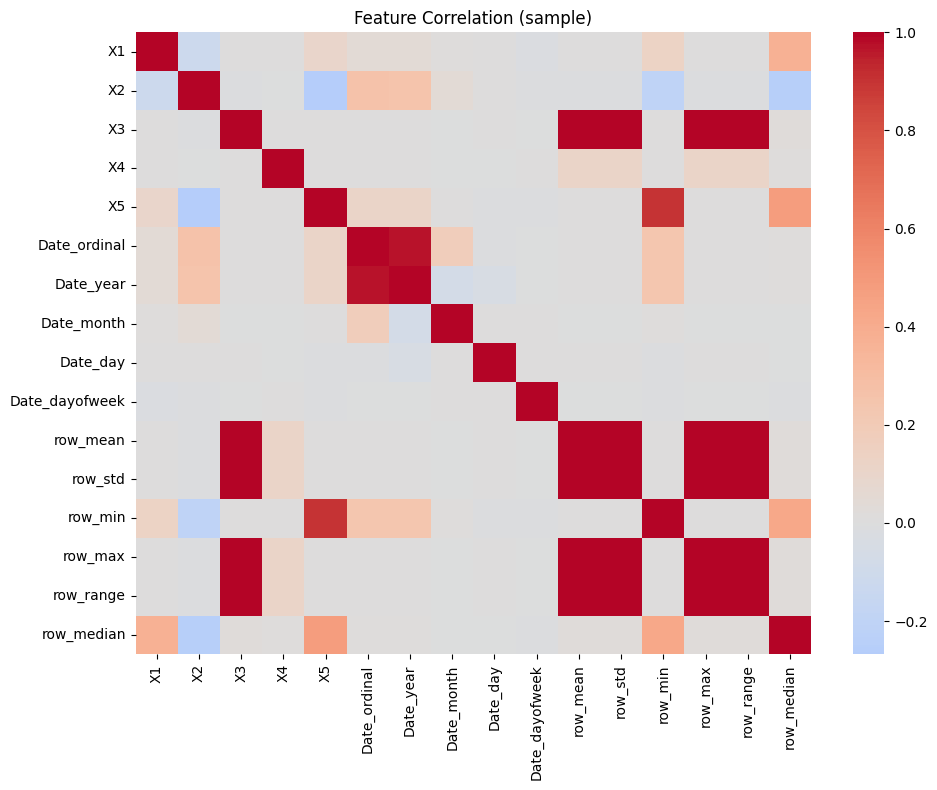

In [27]:
# =============================
# Correlation analysis (sampled)
# =============================

import seaborn as sns
from matplotlib import pyplot as plt

n = min(cfg.corr_sample_rows, len(train_df))
train_sample = train_df.sample(n=n, random_state=cfg.random_state)

X_s = prepare_features(train_sample, cfg)
X_s = X_s.astype(np.float32)

# Compute correlation among all numeric features in the sample
corr = X_s.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation (sample)")
plt.tight_layout()
plt.show()


In [28]:
# =============================
# Metrics + threshold tuning
# =============================

def per_class_metrics(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    per_class_acc = np.divide(
        cm.diagonal(),
        cm.sum(axis=1),
        out=np.zeros_like(cm.diagonal(), dtype=float),
        where=cm.sum(axis=1) != 0,
    )
    per_class_f1 = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    per_class_precision = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    per_class_recall = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

    return pd.DataFrame(
        {
            "class": labels,
            "f1": per_class_f1,
            "precision": per_class_precision,
            "recall": per_class_recall,
            "class_accuracy(recall)": per_class_acc,
            "support": cm.sum(axis=1),
        }
    )


def find_best_threshold(y_true, y_proba_pos, threshold_grid):
    best_t = 0.5
    best_f1 = -1.0
    for t in threshold_grid:
        y_pred = (y_proba_pos >= t).astype(int)
        score = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = float(t)
    return best_t, best_f1


def get_proba_pos(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-scores))
    raise ValueError("Model has neither predict_proba nor decision_function")


In [29]:
# =============================
# Preprocessing + model zoo
# =============================

prep = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)


def make_pipe(model):
    return Pipeline(steps=[("prep", prep), ("model", model)])


models = {
    "LogisticRegression": make_pipe(
        LogisticRegression(
            max_iter=5000,
            solver="saga",
            class_weight="balanced",
            n_jobs=-1,
            random_state=cfg.random_state,
        )
    ),
    "DecisionTree": make_pipe(
        DecisionTreeClassifier(
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=cfg.random_state,
        )
    ),
    "RandomForest": make_pipe(
        RandomForestClassifier(
            n_estimators=300,
            n_jobs=-1,
            class_weight="balanced",
            random_state=cfg.random_state,
        )
    ),
    "SVC(subset)": make_pipe(
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=cfg.random_state,
        )
    ),
    "KNN(subset)": make_pipe(
        KNeighborsClassifier(n_neighbors=35, weights="distance")
    ),
    "MLP(subset)": make_pipe(
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            alpha=1e-4,
            max_iter=30,
            early_stopping=True,
            random_state=cfg.random_state,
        )
    ),
}

# Advanced boosters if available
neg = float(np.sum(y_train == 0))
pos = float(np.sum(y_train == 1))
scale_pos_weight = neg / max(pos, 1.0)

try:
    from xgboost import XGBClassifier
    models["XGBoost(subset)"] = make_pipe(
        XGBClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            random_state=cfg.random_state,
        )
    )
except Exception as e:
    print("[Skip XGBoost]", e)

try:
    from lightgbm import LGBMClassifier
    models["LightGBM(subset)"] = make_pipe(
        LGBMClassifier(
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=32,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary",
            class_weight="balanced",
            n_jobs=-1,
            random_state=cfg.random_state,
        )
    )
except Exception as e:
    print("[Skip LightGBM]", e)

try:
    from catboost import CatBoostClassifier
    models["CatBoost(subset)"] = make_pipe(
        CatBoostClassifier(
            iterations=800,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            verbose=False,
            random_seed=cfg.random_state,
            class_weights=[1.0, scale_pos_weight],
        )
    )
except Exception as e:
    print("[Skip CatBoost]", e)

print("Models:", list(models.keys()))


[Skip XGBoost] 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/pranavanand/Desktop/Kaggle/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/pranavanand/Desktop/Kaggle/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/li

In [31]:
# =============================
# Evaluate models on the validation split
# (tune threshold to maximize F1 for class 1)
# =============================

labels = np.array([0, 1])

slow_subset_frac = 0.05
n_slow = int(len(X_train) * slow_subset_frac)
rng = np.random.RandomState(cfg.random_state)
subset_idx = rng.choice(len(X_train), size=n_slow, replace=False)
X_train_slow = X_train.iloc[subset_idx]
y_train_slow = y_train[subset_idx]

best = {"name": None, "f1_pos": -1.0, "threshold": 0.5, "model": None}

for name, pipe in models.items():
    print("\n===", name, "===")
    if "(subset)" in name or "subset" in name.lower():
        X_use, y_use = X_train_slow, y_train_slow
    else:
        X_use, y_use = X_train, y_train

    model = clone(pipe)
    model.fit(X_use, y_use)

    proba = get_proba_pos(model, X_valid)
    thr, f1_val = find_best_threshold(y_valid, proba, cfg.threshold_grid)
    pred = (proba >= thr).astype(int)

    acc = accuracy_score(y_valid, pred)
    f1_pos = f1_score(y_valid, pred, pos_label=1, zero_division=0)
    f1_macro = f1_score(y_valid, pred, average="macro", zero_division=0)

    per_cls = per_class_metrics(y_valid, pred, labels=labels)
    print("Best threshold:", thr)
    print(f"Valid metrics: F1(pos=1)={f1_pos:.6f} | F1(macro)={f1_macro:.6f} | Accuracy={acc:.6f}")
    print("Per-class metrics:\n", per_cls)

    if f1_pos > best["f1_pos"]:
        best.update({"name": name, "f1_pos": float(f1_pos), "threshold": float(thr), "model": model})

print("\nBest by F1(pos=1):", best["name"], "F1:", best["f1_pos"], "threshold:", best["threshold"])



=== LogisticRegression ===
Best threshold: 0.9400000000000001
Valid metrics: F1(pos=1)=0.479985 | F1(macro)=0.737876 | Accuracy=0.991601
Per-class metrics:
    class        f1  precision    recall  class_accuracy(recall)  support
0      0  0.995766   0.995277  0.996256                0.996256   325077
1      1  0.479985   0.510852  0.452635                0.452635     2808

=== DecisionTree ===
Best threshold: 0.99
Valid metrics: F1(pos=1)=0.677649 | F1(macro)=0.837501 | Accuracy=0.994748
Per-class metrics:
    class        f1  precision    recall  class_accuracy(recall)  support
0      0  0.997353   0.996933  0.997773                0.997773   325077
1      1  0.677649   0.714286  0.644587                0.644587     2808

=== RandomForest ===
Best threshold: 0.35000000000000003
Valid metrics: F1(pos=1)=0.771363 | F1(macro)=0.884756 | Accuracy=0.996328
Per-class metrics:
    class        f1  precision    recall  class_accuracy(recall)  support
0      0  0.998149   0.997612  0.998686 

RuntimeError: Cannot clone object CatBoostClassifier(class_weights=[1.0, 115.78886910062333], depth=6, iterations=800, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False), as the constructor either does not set or modifies parameter class_weights

In [32]:
# =============================
# Cross-validation (on a stratified subset)
# =============================

subset_rows = min(cfg.cv_subset_rows, len(X_all))

X_cv, _, y_cv, _ = train_test_split(
    X_all,
    y_all,
    train_size=subset_rows,
    random_state=cfg.random_state,
    stratify=y_all,
)

skf = StratifiedKFold(n_splits=cfg.cv_folds, shuffle=True, random_state=cfg.random_state)

# Use the best model as a starting point; also include LogisticRegression baseline.
cv_models = {"best_candidate": best["model"]}
cv_models["LogisticRegression"] = models["LogisticRegression"]

for mname, m in cv_models.items():
    if m is None:
        continue

    f1s = []
    oof_proba = np.zeros(len(y_cv), dtype=float)
    oof_pred = np.zeros(len(y_cv), dtype=int)

    # Work with indices inside X_cv
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cv, y_cv), start=1):
        X_tr = X_cv.iloc[tr_idx]
        y_tr = y_cv[tr_idx]
        X_va = X_cv.iloc[va_idx]
        y_va = y_cv[va_idx]

        mm = clone(m)
        mm.fit(X_tr, y_tr)
        proba_va = get_proba_pos(mm, X_va)

        # Default threshold for fold score
        pred_va = (proba_va >= 0.5).astype(int)
        f1s.append(f1_score(y_va, pred_va, pos_label=1, zero_division=0))

        oof_proba[va_idx] = proba_va
        oof_pred[va_idx] = pred_va

    mean_f1 = float(np.mean(f1s))
    std_f1 = float(np.std(f1s))
    # Threshold tune on OOF probabilities for class 1
    thr_oof, _ = find_best_threshold(y_cv, oof_proba, cfg.threshold_grid)
    pred_oof_thr = (oof_proba >= thr_oof).astype(int)
    f1_thr = f1_score(y_cv, pred_oof_thr, pos_label=1, zero_division=0)

    per_cls_oof = per_class_metrics(y_cv, pred_oof_thr, labels=labels)
    print(f"\n[CV] {mname}: F1(pos=1) @0.5 mean={mean_f1:.6f} std={std_f1:.6f}")
    print(f"[CV] {mname}: OOF best threshold={thr_oof:.4f} -> F1(pos=1)={f1_thr:.6f}")
    print("[CV] Per-class (OOF, best-threshold):\n", per_cls_oof)



[CV] best_candidate: F1(pos=1) @0.5 mean=0.524368 std=0.022200
[CV] best_candidate: OOF best threshold=0.3300 -> F1(pos=1)=0.598873
[CV] Per-class (OOF, best-threshold):
    class        f1  precision    recall  class_accuracy(recall)  support
0      0  0.996988   0.995874  0.998104                0.998104   247859
1      1  0.598873   0.703657  0.521252                0.521252     2141

[CV] LogisticRegression: F1(pos=1) @0.5 mean=0.128483 std=0.002304
[CV] LogisticRegression: OOF best threshold=0.9700 -> F1(pos=1)=0.401522
[CV] Per-class (OOF, best-threshold):
    class        f1  precision    recall  class_accuracy(recall)  support
0      0  0.994282   0.995186  0.993379                0.993379   247859
1      1  0.401522   0.366654  0.443718                0.443718     2141


In [33]:
# =============================
# Hyperparameter tuning (RandomizedSearchCV) for LightGBM/XGBoost if available
# =============================

tuning_sub_rows = min(len(X_train), 60000)
rng = np.random.RandomState(cfg.random_state)
idx = rng.choice(len(X_train), size=tuning_sub_rows, replace=False)
X_tune = X_train.iloc[idx]
y_tune = y_train[idx]

best_tuned = None

# Decide which booster is available
if "LightGBM" in models:
    print("Tuning LightGBM...")
    from lightgbm import LGBMClassifier
    base = make_pipe(
        LGBMClassifier(
            objective="binary",
            class_weight="balanced",
            n_jobs=-1,
            random_state=cfg.random_state,
        )
    )
    param_dist = {
        "model__n_estimators": [500, 800, 1200, 1600],
        "model__learning_rate": [0.01, 0.02, 0.03, 0.05],
        "model__num_leaves": [31, 63, 127],
        "model__min_child_samples": [10, 20, 40],
        "model__subsample": [0.7, 0.85, 0.95],
        "model__colsample_bytree": [0.7, 0.85, 0.95],
    }
    search = RandomizedSearchCV(
        estimator=base,
        param_distributions=param_dist,
        n_iter=5,
        scoring="f1",
        cv=2,
        verbose=0,
        n_jobs=-1,
        refit=True,
        random_state=cfg.random_state,
    )
    search.fit(X_tune, y_tune)
    best_tuned = search.best_estimator_
    print("LightGBM best params:\n", search.best_params_)

elif "XGBoost" in models:
    print("Tuning XGBoost...")
    from xgboost import XGBClassifier
    base = make_pipe(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            random_state=cfg.random_state,
        )
    )
    param_dist = {
        "model__n_estimators": [300, 500, 800, 1200],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.08],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.7, 0.85, 0.95],
        "model__colsample_bytree": [0.7, 0.85, 0.95],
        "model__reg_lambda": [0.1, 1.0, 5.0],
    }
    search = RandomizedSearchCV(
        estimator=base,
        param_distributions=param_dist,
        n_iter=5,
        scoring="f1",
        cv=2,
        verbose=0,
        n_jobs=-1,
        refit=True,
        random_state=cfg.random_state,
    )
    search.fit(X_tune, y_tune)
    best_tuned = search.best_estimator_
    print("XGBoost best params:\n", search.best_params_)
else:
    print("No LightGBM/XGBoost available; skipping booster tuning.")

# If tuned booster exists, re-evaluate it on the validation split with threshold tuning
if best_tuned is not None:
    proba = get_proba_pos(best_tuned, X_valid)
    thr, f1_pos = find_best_threshold(y_valid, proba, cfg.threshold_grid)
    pred = (proba >= thr).astype(int)
    acc = accuracy_score(y_valid, pred)
    print("\n[Tuned eval] threshold:", thr, "F1(pos=1):", f1_pos, "Accuracy:", acc)
    print(per_class_metrics(y_valid, pred, labels=labels))
    if f1_pos > best["f1_pos"]:
        best.update({"name": "tuned_booster", "f1_pos": float(f1_pos), "threshold": float(thr), "model": best_tuned})

print("\nFinal best:", best["name"], "F1(pos=1):", best["f1_pos"], "threshold:", best["threshold"])


No LightGBM/XGBoost available; skipping booster tuning.

Final best: RandomForest F1(pos=1): 0.771363463729586 threshold: 0.35000000000000003


Confusion matrix:
         pred_0  pred_1
true_0  324650     427
true_1     777    2031

Classification report:
               precision    recall  f1-score   support

           0     0.9976    0.9987    0.9981    325077
           1     0.8263    0.7233    0.7714      2808

    accuracy                         0.9963    327885
   macro avg     0.9119    0.8610    0.8848    327885
weighted avg     0.9961    0.9963    0.9962    327885



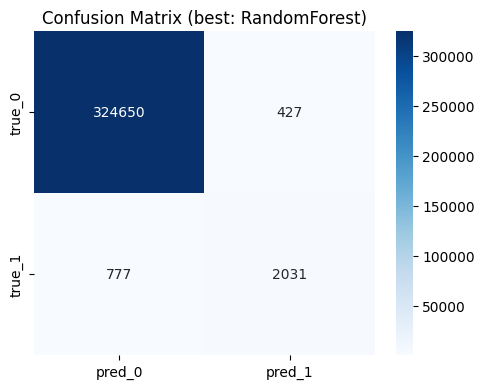

In [34]:
# =============================
# Residual-style / error analysis on validation
# =============================

from matplotlib import pyplot as plt
import seaborn as sns

best_model = best["model"]
best_thr = best["threshold"]

proba = get_proba_pos(best_model, X_valid)
pred = (proba >= best_thr).astype(int)

cm = confusion_matrix(y_valid, pred, labels=labels)
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
print("Confusion matrix:\n", cm_df)

print("\nClassification report:\n", classification_report(y_valid, pred, digits=4))

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (best: {best['name']})")
plt.tight_layout()
plt.show()


In [35]:
# =============================
# Train on full data + generate submission
# =============================

# Recompute clip bounds on full training features
X_full = prepare_features(train_df, cfg)
y_full = train_df[cfg.target_col].values.astype(int)

lower_full, upper_full = fit_clip_bounds(X_full, clip_cols, cfg.clip_lower_q, cfg.clip_upper_q)
X_full = apply_clip_bounds(X_full, clip_cols, lower_full, upper_full)
X_full = X_full.astype(np.float32)

# Prepare test
X_test = prepare_features(test_df, cfg)
X_test = apply_clip_bounds(X_test, clip_cols, lower_full, upper_full)
X_test = X_test.astype(np.float32)

# Fit best model
final_model = clone(best_model)
final_model.fit(X_full, y_full)

# Predict
test_proba = get_proba_pos(final_model, X_test)
test_pred = (test_proba >= best_thr).astype(int)

# Write submission
sample_paths = [p for p in os.listdir(".") if "sample_submission" in p and p.endswith(".csv")]
if sample_paths:
    sample_path = sample_paths[0]
    sample_sub = pd.read_csv(sample_path)
    target_cols = [c for c in sample_sub.columns if c != cfg.id_col]
    if len(target_cols) == 1:
        target_out_col = target_cols[0]
    else:
        target_out_col = cfg.target_col
    sub = pd.DataFrame({cfg.id_col: test_df[cfg.id_col].values, target_out_col: test_pred})
else:
    # Default format: ID + target
    sub = pd.DataFrame({cfg.id_col: test_df[cfg.id_col].values, cfg.target_col: test_pred})

out_path = "submission.csv"
sub.to_csv(out_path, index=False)
print("Saved:", out_path, "| shape:", sub.shape)
print(sub.head())


Saved: submission.csv | shape: (409856, 2)
   ID  target
0   0       0
1   1       1
2   2       0
3   3       0
4   4       0
